## Name: Hadi Abu Allairat
## ID: 2230005761
## Section: 8MA1

## Step 1:
Import necessary libraries:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 2: 
Unsharp Masking

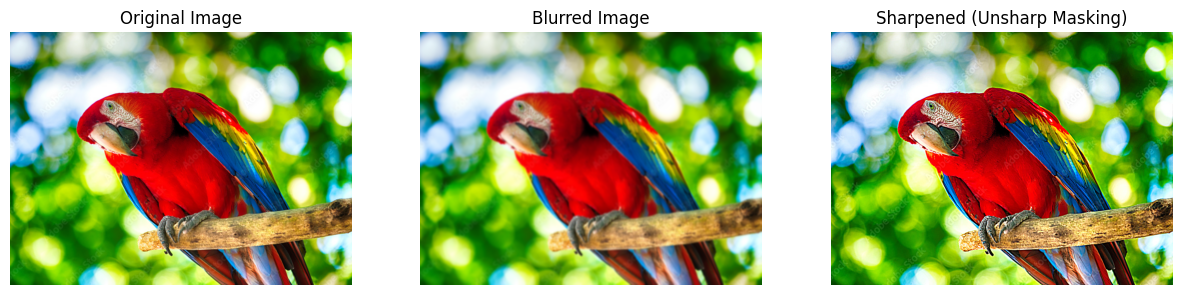

In [2]:
# Read the image
image = cv2.imread('images/Parrot.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma=2

#parameter
amount=1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)
# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")

plt.show() 

## Task 1:
Convolve an image with a 7x7 box filter, and output the original and smoothed image side by side

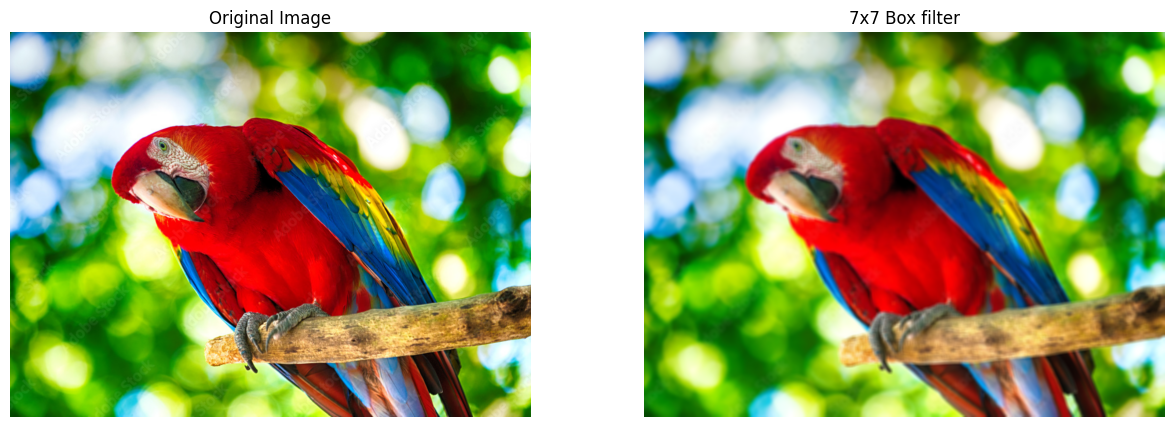

In [3]:
kernel = np.ones((7, 7),np.float32)/49
blurred_box = cv2.filter2D(image, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred_box)
ax[1].set_title("7x7 Box filter")
ax[1].axis("off")

plt.show()

## Task 2:
Using an image of your choice, apply a 5x5 Gaussian filter to the image, then a 21x21 Gaussian filter, and show the three images side by side.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00018035459..1.0000001].


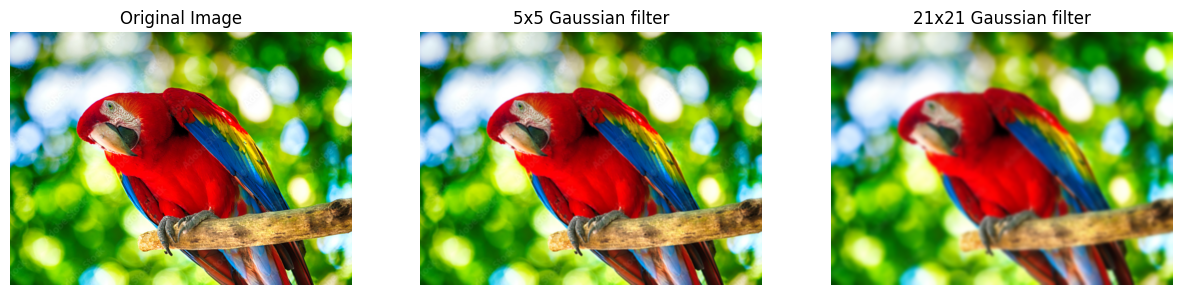

In [4]:
# Apply Gaussian blur
kernel_size = (5, 5)
blurred_5 = cv2.GaussianBlur(image_float, ksize=kernel_size, sigmaX=0)
kernel_size = (21, 21)
blurred_21 = cv2.GaussianBlur(image_float, ksize=kernel_size, sigmaX=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred_5)
ax[1].set_title("5x5 Gaussian filter")
ax[1].axis("off")

ax[2].imshow(blurred_21)
ax[2].set_title("21x21 Gaussian filter")
ax[2].axis("off")

plt.show() 

## Task 3:
Using an image of your choice, apply a 3x3 Laplacian filter to sharpen the image. Follow the following steps:

### Task 3.1:
Read the image

In [5]:
unclear_text = cv2.imread('images/Unclear_Text.png')
unclear_text = cv2.cvtColor(unclear_text, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

### Task 3.2:
Convert image to float32

In [6]:
unclear_text_float = unclear_text.astype(np.float32) / 255.0

### Task 3.3:
Use the cv2.Laplacian() function

In [7]:
unclear_text_L = cv2.Laplacian(unclear_text_float, cv2.CV_32F, ksize=3)

### Task 3.4:
Sharpen the image using: np.clip(image_float - laplacian, 0, 1)

In [8]:
sharpened_text = np.clip(unclear_text_float - unclear_text_L, 0, 1)

### Task 3.5:
Plot the original image, the resulting image after applying the Laplacian filter, and the sharpened image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.729412..5.921569].


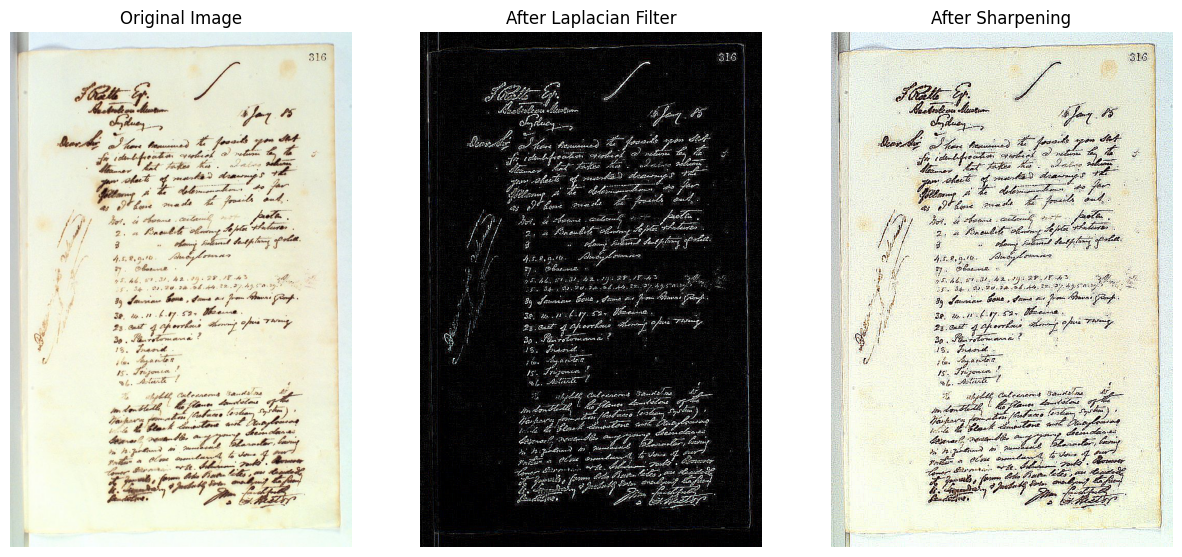

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 20))
ax[0].imshow(unclear_text)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(unclear_text_L)
ax[1].set_title("After Laplacian Filter")
ax[1].axis("off")

ax[2].imshow(sharpened_text)
ax[2].set_title("After Sharpening")
ax[2].axis("off")

plt.show()